# Credit Card Fraud Detection

### Project goal
Build and compare fraud detection models on an imbalanced transaction dataset, then connect the model output to a simple **business cost analysis**.

## Notebook Structure

1. Imports and display settings
2. File paths
3. Load datasets
4. Helper functions
5. Feature engineering
6. Categorical encoding
7. Prepare modeling dataset
8. Exploratory analysis
9. Feature selection
10. Scaling for Logistic Regression
11. Baseline Logistic Regression
12. Logistic Regression with SMOTE and ADASYN
13. Decision Tree models
14. Random Forest models
15. Model comparison
16. Holdout test evaluation
17. Fraud prediction sample output
18. Business cost analysis
19. Final notes and next steps

## 1. Imports and display settings

In this section, we import the libraries required for data preparation, visualization, model building, imbalance handling, and evaluation.

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Libraries imported successfully.")
print(f"Random state: {RANDOM_STATE} | Test size: {TEST_SIZE}")

Libraries imported successfully.
Random state: 42 | Test size: 0.2


## 2. File paths

This notebook is portable.  
It first checks the current folder and then a `data/` folder, so it can run both:
- in a local Jupyter Notebook setup
- in a GitHub-friendly project structure

In [6]:
DATA_FILE = Path("creditcard.csv")
ALT_DATA_FILE = Path("data/creditcard.csv")

if DATA_FILE.exists():
    csv_path = DATA_FILE
elif ALT_DATA_FILE.exists():
    csv_path = ALT_DATA_FILE
else:
    raise FileNotFoundError(
        "Could not find 'creditcard.csv'. Place it in the notebook folder or inside a 'data/' folder."
    )

print(f"Using dataset: {csv_path.resolve()}")

Using dataset: C:\Users\dshob\Assignments\Project (Credit-card-fraud-detection)\creditcard.csv


## 3. Load datasets

Although the original capstone notebook worked with separate train/test files, this dataset is a **single file**.
So in this project:
- we load one dataset
- inspect its schema
- later create our own **train/test split**

This is a more standard and interviewer-friendly workflow because it avoids relying on pre-split files.

In [8]:
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "nunique": df.nunique().values
})

display(column_summary)

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,column,dtype,missing_values,nunique
0,Time,float64,0,124592
1,V1,float64,0,275663
2,V2,float64,0,275663
3,V3,float64,0,275663
4,V4,float64,0,275663
5,V5,float64,0,275663
6,V6,float64,0,275663
7,V7,float64,0,275663
8,V8,float64,0,275663
9,V9,float64,0,275663


In [9]:
required_columns = {"Time", "Amount", "Class"}
missing_required = required_columns - set(df.columns)

if missing_required:
    raise ValueError(f"Dataset is missing required columns: {missing_required}")

print("Required columns are present.")
print("Target column distribution:")
display(df["Class"].value_counts().rename("count").to_frame())
display(df["Class"].value_counts(normalize=True).rename("proportion").to_frame())

Required columns are present.
Target column distribution:


,count
Class,
0,284315
1,492


,proportion
Class,
0,0.998273
1,0.001727


## 4. Helper functions

These helper functions keep the notebook readable and make the evaluation section easier to explain.
They are written once here so the later modeling sections stay clean and focused.

In [11]:
def model_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
    }

def confusion_dataframe(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(
        cm,
        index=["Actual_0", "Actual_1"],
        columns=["Pred_0", "Pred_1"]
    )

def evaluate_model(name, y_true, y_pred, y_proba):
    return pd.DataFrame([{ "Model": name, **model_metrics(y_true, y_pred, y_proba) }])

def business_cost_summary(y_true, y_pred, fn_cost=500, fp_cost=10):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Cost_per_FP": fp_cost,
        "Cost_per_FN": fn_cost,
        "Estimated_Total_Cost": total_cost
    }

def find_best_threshold_by_f1(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 19)
    rows = []
    for threshold in thresholds:
        preds = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
        })
    threshold_df = pd.DataFrame(rows).sort_values(["f1", "recall", "precision"], ascending=False)
    return threshold_df.reset_index(drop=True)

def feature_selection_report(X_train, y_train, sample_size=50000, random_state=42):
    sample_n = min(sample_size, len(X_train))
    sampled_idx = X_train.sample(n=sample_n, random_state=random_state).index
    X_sample = X_train.loc[sampled_idx]
    y_sample = y_train.loc[sampled_idx]

    mi = mutual_info_classif(X_sample, y_sample, random_state=random_state)
    mi_df = pd.DataFrame({
        "feature": X_sample.columns,
        "mutual_information": mi
    }).sort_values("mutual_information", ascending=False).reset_index(drop=True)
    return mi_df

## 5. Feature engineering

The original capstone notebook included richer feature engineering because that dataset had dates, merchants, categories, geolocation, and customer attributes.

This dataset is more compressed and anonymized, but we can still add useful derived features:

- **Amount_log**: reduces the heavy skew in transaction amounts  
- **Hour**: approximate hour of transaction from the `Time` variable  
- **Time_days**: converts time from seconds into days for easier interpretation  
- **Hour_sin / Hour_cos**: cyclical encoding for time-of-day patterns  
- **Amount_zscore**: standardized amount signal  
- **Amount_is_zero**: flags zero-amount edge cases  

These features make the notebook more presentation-ready while staying valid for this dataset.

In [13]:
work_df = df.copy()

work_df["Amount_log"] = np.log1p(work_df["Amount"])
work_df["Hour"] = ((work_df["Time"] // 3600) % 24).astype(int)
work_df["Time_days"] = work_df["Time"] / (24 * 3600)
work_df["Hour_sin"] = np.sin(2 * np.pi * work_df["Hour"] / 24)
work_df["Hour_cos"] = np.cos(2 * np.pi * work_df["Hour"] / 24)

amount_mean = work_df["Amount"].mean()
amount_std = work_df["Amount"].std(ddof=0)
work_df["Amount_zscore"] = (work_df["Amount"] - amount_mean) / amount_std
work_df["Amount_is_zero"] = (work_df["Amount"] == 0).astype(int)

print("Feature engineering completed.")
display(work_df.head())

Feature engineering completed.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Hour,Time_days,Hour_sin,Hour_cos,Amount_zscore,Amount_is_zero
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0,0.000000,0.0,1.0,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0,0.000000,0.0,1.0,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0,0.000012,0.0,1.0,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0,0.000012,0.0,1.0,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0,0.000023,0.0,1.0,-0.073403,0


### Note

> “The dataset already had strong anonymized numeric predictors, so I kept the original variables and added lightweight business-style features around transaction amount and transaction timing. This gave me a more explainable pipeline without inventing unrealistic transformations.”

## 6. Categorical encoding

This dataset is already numeric, so there are no categorical columns to encode.

I still keep this section in the notebook because:
- it preserves the full workflow structure
- it shows I checked the data properly
- it demonstrates how the pipeline would scale to richer fraud datasets

In [16]:
categorical_cols = work_df.select_dtypes(include=["object", "category"]).columns.tolist()

if categorical_cols:
    work_df = pd.get_dummies(work_df, columns=categorical_cols, drop_first=True)
    print("Encoded categorical columns:", categorical_cols)
else:
    print("No categorical columns found. Encoding is not required for this dataset.")

No categorical columns found. Encoding is not required for this dataset.


## 7. Prepare modeling dataset

This is where we define:
- **X** = input features
- **y** = target label

We then split the data into train and test sets using **stratification**.
That is important because fraud datasets are highly imbalanced, and we want the fraud ratio to remain similar in both sets.

In [18]:
TARGET = "Class"

X = work_df.drop(columns=[TARGET]).copy()
y = work_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nClass distribution (full dataset):")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

print("\nClass distribution (train):")
display(y_train.value_counts(normalize=True).rename("proportion").to_frame())

print("\nClass distribution (test):")
display(y_test.value_counts(normalize=True).rename("proportion").to_frame())


Training shape: (227845, 37)
Test shape: (56962, 37)

Class distribution (full dataset):


,proportion
Class,
0,0.998273
1,0.001727



Class distribution (train):


,proportion
Class,
0,0.998271
1,0.001729



Class distribution (test):


,proportion
Class,
0,0.99828
1,0.00172


## 8. Exploratory analysis

The purpose of the EDA section is to answer a few business and modeling questions:

1. How imbalanced is the target?
2. Are transaction amounts skewed?
3. Do frauds show different amount patterns?
4. Which features appear most correlated with the fraud label?

For an interviewer, this shows that the project is not just “fit models and compare scores”.

In [20]:
eda_summary = pd.DataFrame({
    "dtype": work_df.dtypes.astype(str),
    "missing": work_df.isna().sum(),
    "nunique": work_df.nunique()
})

display(eda_summary.head(15))

class_counts = work_df["Class"].value_counts().sort_index()
class_props = work_df["Class"].value_counts(normalize=True).sort_index()

print("Class counts:")
display(class_counts.rename("count").to_frame())

print("Class proportions:")
display(class_props.rename("proportion").to_frame())

,dtype,missing,nunique
Time,float64,0,124592
V1,float64,0,275663
V2,float64,0,275663
V3,float64,0,275663
V4,float64,0,275663
V5,float64,0,275663
V6,float64,0,275663
V7,float64,0,275663
V8,float64,0,275663
V9,float64,0,275663


Class counts:


,count
Class,
0,284315
1,492


Class proportions:


,proportion
Class,
0,0.998273
1,0.001727


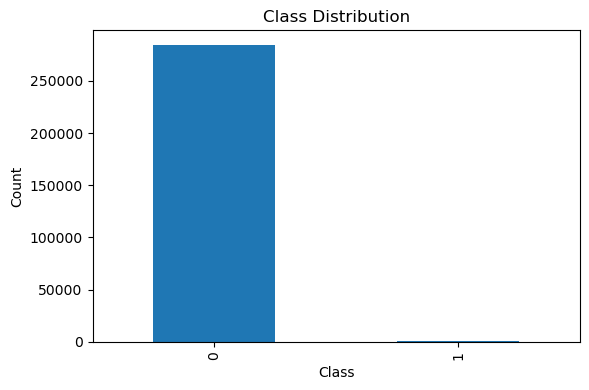

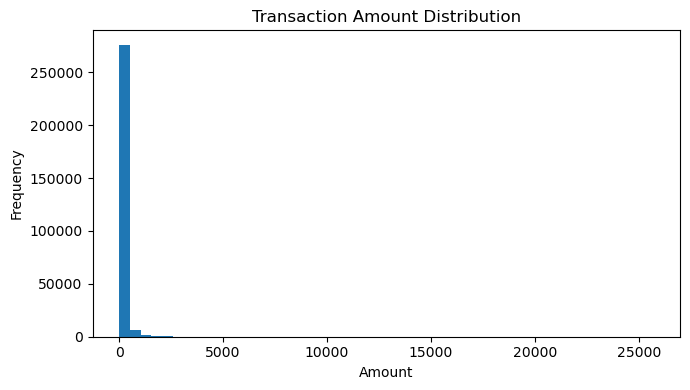

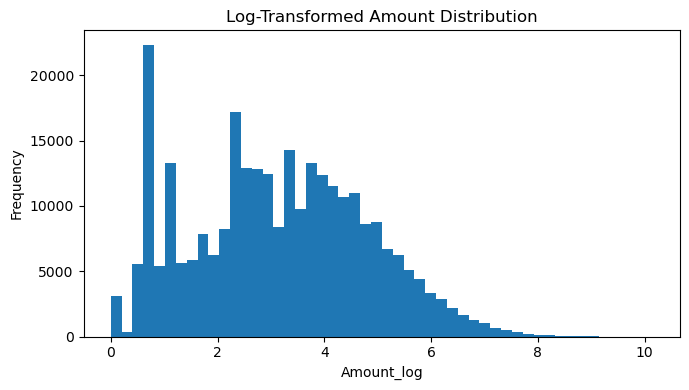

In [21]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
work_df["Amount"].plot(kind="hist", bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
work_df["Amount_log"].plot(kind="hist", bins=50)
plt.title("Log-Transformed Amount Distribution")
plt.xlabel("Amount_log")
plt.tight_layout()
plt.show()

In [22]:
amount_by_class = work_df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"]).round(2)
log_amount_by_class = work_df.groupby("Class")["Amount_log"].agg(["mean", "median"]).round(4)

print("Amount summary by class:")
display(amount_by_class)

print("Log amount summary by class:")
display(log_amount_by_class)

Amount summary by class:


,count,mean,median,max
Class,,,,
0,284315,88.29,22.00,25691.16
1,492,122.21,9.25,2125.87


Log amount summary by class:


,mean,median
Class,,
0,3.1528,3.1355
1,2.8206,2.3273


Top absolute correlations with the target:


,correlation_with_Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


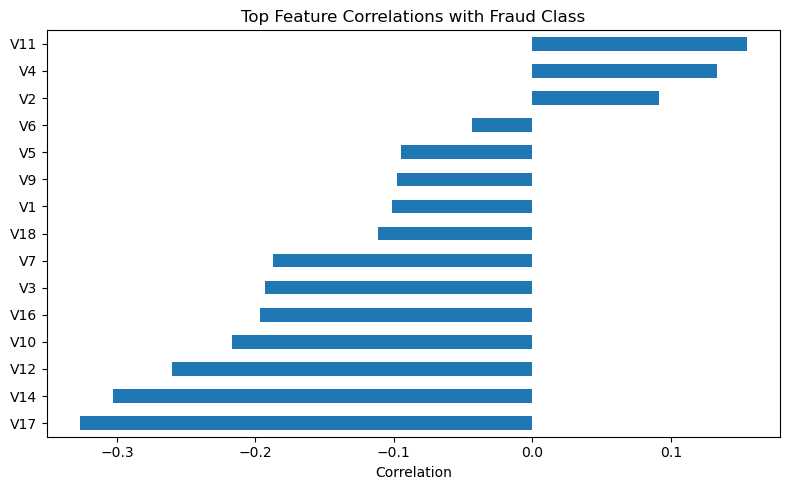

In [23]:
corr_with_target = work_df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
top_corr = corr_with_target.head(15).rename("correlation_with_Class").to_frame()

print("Top absolute correlations with the target:")
display(top_corr)

plt.figure(figsize=(8, 5))
top_corr["correlation_with_Class"].sort_values().plot(kind="barh")
plt.title("Top Feature Correlations with Fraud Class")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## 9. Feature selection

This dataset already contains carefully engineered and anonymized numeric features, so aggressive manual feature dropping is usually unnecessary.

Still, to make the workflow complete, I apply two light checks:

1. Remove any **zero-variance** columns  
2. Compute a **mutual information report** on a sample of the training data to understand which variables carry signal

This gives a more interview-ready explanation than simply saying “I used all columns”.

In [25]:
nunique_train = X_train.nunique()
selected_features = nunique_train[nunique_train > 1].index.tolist()

X_train_fs = X_train[selected_features].copy()
X_test_fs = X_test[selected_features].copy()

print(f"Selected {len(selected_features)} features out of {X_train.shape[1]}.")
print("First 15 selected features:")
print(selected_features[:15])

Selected 37 features out of 37.
First 15 selected features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']


,feature,mutual_information
0,V17,0.006619
1,V14,0.006110
2,V12,0.005946
3,V10,0.005764
4,V11,0.005186
5,V16,0.004330
6,V4,0.003467
7,V3,0.003418
8,V7,0.003005
9,V9,0.002390


<Figure size 800x500 with 0 Axes>

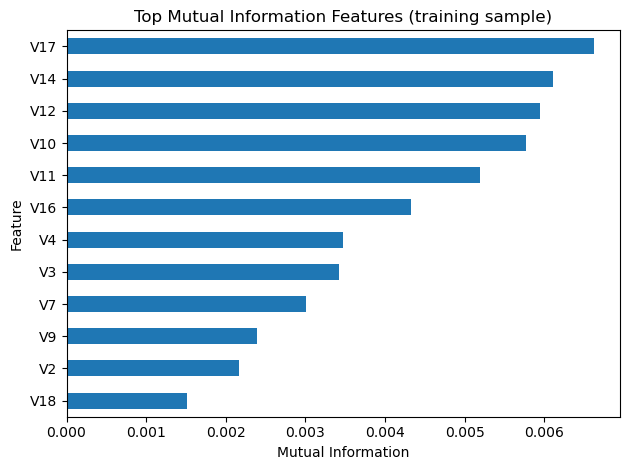

In [26]:
mi_report = feature_selection_report(X_train_fs, y_train, sample_size=50000, random_state=RANDOM_STATE)
display(mi_report.head(15))

plt.figure(figsize=(8, 5))
mi_report.head(12).iloc[::-1].plot(
    x="feature",
    y="mutual_information",
    kind="barh",
    legend=False
)
plt.title("Top Mutual Information Features (training sample)")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Note

> “Because the credit card dataset already uses transformed variables like V1–V28, I avoided over-pruning. I only removed zero-variance features and then used mutual information as a lightweight diagnostic to understand which variables were most informative.”

## 10. Scaling for Logistic Regression

Logistic Regression is sensitive to feature scale, especially when the dataset combines:
- PCA-like variables
- raw `Time`
- raw `Amount`
- engineered features like `Amount_log`

So I scale the data only for Logistic Regression.
Tree-based models in later sections will use the unscaled feature set.

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_fs)
X_test_scaled = scaler.transform(X_test_fs)

print("Scaling complete.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaling complete.
Scaled training shape: (227845, 37)
Scaled test shape: (56962, 37)


## 11. Baseline Logistic Regression

This is the simplest baseline model in the notebook.

Why start here?
- Logistic Regression is fast and interpretable
- it gives a strong baseline for tabular binary classification
- it helps show whether the engineered features and standardized inputs are already enough to detect fraud patterns

In [31]:
baseline_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_lr.fit(X_train_scaled, y_train)

baseline_lr_pred = baseline_lr.predict(X_test_scaled)
baseline_lr_proba = baseline_lr.predict_proba(X_test_scaled)[:, 1]

baseline_lr_results = evaluate_model(
    "Baseline Logistic Regression",
    y_test,
    baseline_lr_pred,
    baseline_lr_proba
)

display(baseline_lr_results)

print(classification_report(y_test, baseline_lr_pred, digits=4))
display(confusion_dataframe(y_test, baseline_lr_pred))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Baseline Logistic Regression,0.99921,0.835443,0.673469,0.745763,0.95992,0.741007


              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8354    0.6735    0.7458        98

    accuracy                         0.9992     56962
   macro avg     0.9174    0.8366    0.8727     56962
weighted avg     0.9992    0.9992    0.9992     56962



,Pred_0,Pred_1
Actual_0,56851,13
Actual_1,32,66


### Interview note
A useful explanation:

> “Accuracy is not the main metric here because the data is extremely imbalanced. I focused more on recall, F1, ROC-AUC, and especially PR-AUC, because precision-recall metrics are more informative for rare fraud detection.”

## 12. Logistic Regression with SMOTE and ADASYN

Fraud detection is an imbalanced learning problem.

To address that, I trained two resampling versions of Logistic Regression:

- **SMOTE**: creates synthetic minority examples in a smoother way  
- **ADASYN**: focuses more on harder minority examples  

Important practical note:
I use a **limited sampling ratio** instead of fully balancing the classes.  
That keeps runtime and memory more reasonable on this dataset while still giving the model more fraud examples to learn from.

In [34]:
smote_lr = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.05)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

adasyn_lr = ImbPipeline(steps=[
    ("adasyn", ADASYN(random_state=RANDOM_STATE, sampling_strategy=0.05)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

smote_lr.fit(X_train_fs, y_train)
adasyn_lr.fit(X_train_fs, y_train)

smote_lr_pred = smote_lr.predict(X_test_fs)
smote_lr_proba = smote_lr.predict_proba(X_test_fs)[:, 1]

adasyn_lr_pred = adasyn_lr.predict(X_test_fs)
adasyn_lr_proba = adasyn_lr.predict_proba(X_test_fs)[:, 1]

lr_resampling_results = pd.concat([
    evaluate_model("Logistic Regression + SMOTE", y_test, smote_lr_pred, smote_lr_proba),
    evaluate_model("Logistic Regression + ADASYN", y_test, adasyn_lr_pred, adasyn_lr_proba),
], ignore_index=True)

display(lr_resampling_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression + SMOTE,0.998841,0.615942,0.867347,0.720339,0.973426,0.740516
1,Logistic Regression + ADASYN,0.998894,0.629630,0.867347,0.729614,0.973833,0.744845


In [35]:
print("SMOTE confusion matrix:")
display(confusion_dataframe(y_test, smote_lr_pred))

print("ADASYN confusion matrix:")
display(confusion_dataframe(y_test, adasyn_lr_pred))

SMOTE confusion matrix:


,Pred_0,Pred_1
Actual_0,56811,53
Actual_1,13,85


ADASYN confusion matrix:


,Pred_0,Pred_1
Actual_0,56814,50
Actual_1,13,85


## 13. Decision Tree models

Decision Trees help capture non-linear interactions and are easy to explain.

I compare:
- a more flexible default-style tree
- a balanced/tuned tree with regularization

This lets me show both:
- how a tree behaves naturally
- how class imbalance and overfitting can be managed

In [37]:
dt_default = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=8,
    min_samples_leaf=10
)

dt_balanced = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=6,
    min_samples_leaf=20
)

dt_default.fit(X_train_fs, y_train)
dt_balanced.fit(X_train_fs, y_train)

dt_default_pred = dt_default.predict(X_test_fs)
dt_default_proba = dt_default.predict_proba(X_test_fs)[:, 1]

dt_balanced_pred = dt_balanced.predict(X_test_fs)
dt_balanced_proba = dt_balanced.predict_proba(X_test_fs)[:, 1]

dt_results = pd.concat([
    evaluate_model("Decision Tree - Default", y_test, dt_default_pred, dt_default_proba),
    evaluate_model("Decision Tree - Balanced", y_test, dt_balanced_pred, dt_balanced_proba),
], ignore_index=True)

display(dt_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree - Default,0.99928,0.880000,0.673469,0.763006,0.901496,0.771607
1,Decision Tree - Balanced,0.97616,0.059441,0.867347,0.111257,0.912268,0.595719


## 14. Random Forest models

Random Forest is often a strong baseline for tabular data because:
- it handles non-linearity well
- it is robust to noise
- it captures feature interactions automatically

I compare:
- a default-style forest
- a class-balanced forest

In [39]:
rf_default = RandomForestClassifier(
    n_estimators=80,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=12,
    min_samples_leaf=2
)

rf_balanced = RandomForestClassifier(
    n_estimators=80,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=12,
    min_samples_leaf=2
)

rf_default.fit(X_train_fs, y_train)
rf_balanced.fit(X_train_fs, y_train)

rf_default_pred = rf_default.predict(X_test_fs)
rf_default_proba = rf_default.predict_proba(X_test_fs)[:, 1]

rf_balanced_pred = rf_balanced.predict(X_test_fs)
rf_balanced_proba = rf_balanced.predict_proba(X_test_fs)[:, 1]

rf_results = pd.concat([
    evaluate_model("Random Forest - Default", y_test, rf_default_pred, rf_default_proba),
    evaluate_model("Random Forest - Balanced", y_test, rf_balanced_pred, rf_balanced_proba),
], ignore_index=True)

display(rf_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Default,0.999579,0.951220,0.795918,0.866667,0.973242,0.861029
1,Random Forest - Balanced,0.999473,0.869565,0.816327,0.842105,0.982285,0.826265


,feature,importance
0,V14,0.155674
1,V10,0.138667
2,V4,0.106285
3,V12,0.104485
4,V17,0.092669
5,V16,0.063741
6,V11,0.059274
7,V3,0.041394
8,V7,0.035967
9,V2,0.016826


<Figure size 800x500 with 0 Axes>

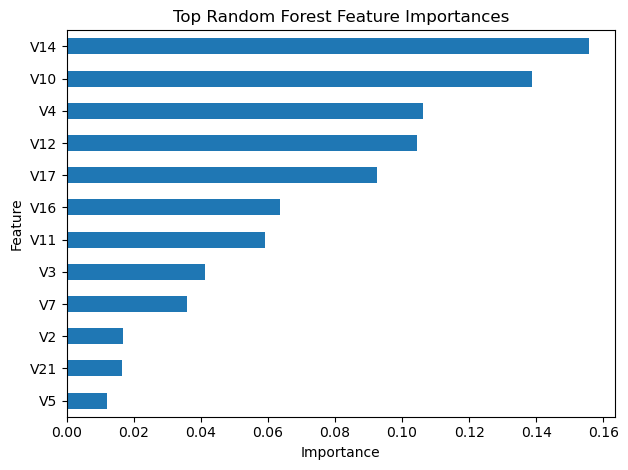

In [40]:
rf_feature_importance = pd.DataFrame({
    "feature": X_train_fs.columns,
    "importance": rf_balanced.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(rf_feature_importance.head(15))

plt.figure(figsize=(8, 5))
rf_feature_importance.head(12).iloc[::-1].plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Model comparison

Now I combine all the models into one comparison table and rank them using:
1. **PR_AUC**
2. **Recall**
3. **F1**

This ranking is more meaningful than accuracy for a fraud detection use case.

In [42]:
comparison_df = pd.concat([
    baseline_lr_results,
    lr_resampling_results,
    dt_results,
    rf_results
], ignore_index=True)

comparison_df = comparison_df.sort_values(
    by=["PR_AUC", "Recall", "F1"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]
print("Best model based on PR_AUC / Recall / F1 ordering:", best_model_name)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Default,0.999579,0.951220,0.795918,0.866667,0.973242,0.861029
1,Random Forest - Balanced,0.999473,0.869565,0.816327,0.842105,0.982285,0.826265
2,Decision Tree - Default,0.999280,0.880000,0.673469,0.763006,0.901496,0.771607
3,Logistic Regression + ADASYN,0.998894,0.629630,0.867347,0.729614,0.973833,0.744845
4,Baseline Logistic Regression,0.999210,0.835443,0.673469,0.745763,0.959920,0.741007
5,Logistic Regression + SMOTE,0.998841,0.615942,0.867347,0.720339,0.973426,0.740516
6,Decision Tree - Balanced,0.976160,0.059441,0.867347,0.111257,0.912268,0.595719


Best model based on PR_AUC / Recall / F1 ordering: Random Forest - Default


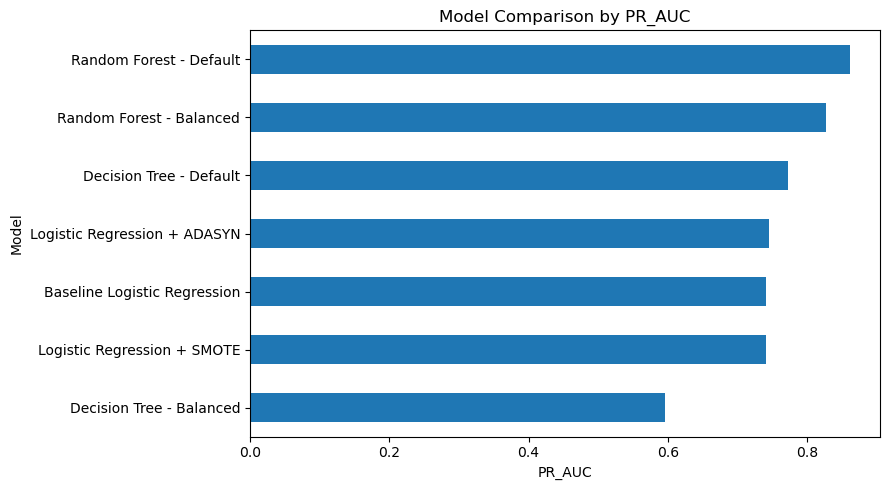

In [43]:
plt.figure(figsize=(9, 5))
comparison_df.set_index("Model")["PR_AUC"].sort_values().plot(kind="barh")
plt.title("Model Comparison by PR_AUC")
plt.xlabel("PR_AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 16. Holdout test evaluation

Here I take the best model from the comparison section and evaluate it more carefully on the holdout test set.

This is also where I add one interviewer-friendly step:
- compare the default threshold of **0.50**
- inspect a simple threshold tuning table based on **F1**

In production, threshold choice should be guided by validation data and business costs, but this section is useful for presentation and discussion.

In [45]:
trained_models = {
    "Baseline Logistic Regression": baseline_lr,
    "Logistic Regression + SMOTE": smote_lr,
    "Logistic Regression + ADASYN": adasyn_lr,
    "Decision Tree - Default": dt_default,
    "Decision Tree - Balanced": dt_balanced,
    "Random Forest - Default": rf_default,
    "Random Forest - Balanced": rf_balanced
}

prediction_store = {
    "Baseline Logistic Regression": (baseline_lr_pred, baseline_lr_proba),
    "Logistic Regression + SMOTE": (smote_lr_pred, smote_lr_proba),
    "Logistic Regression + ADASYN": (adasyn_lr_pred, adasyn_lr_proba),
    "Decision Tree - Default": (dt_default_pred, dt_default_proba),
    "Decision Tree - Balanced": (dt_balanced_pred, dt_balanced_proba),
    "Random Forest - Default": (rf_default_pred, rf_default_proba),
    "Random Forest - Balanced": (rf_balanced_pred, rf_balanced_proba),
}

best_pred, best_proba = prediction_store[best_model_name]

print(f"Best holdout model: {best_model_name}")
print(classification_report(y_test, best_pred, digits=4))
display(confusion_dataframe(y_test, best_pred))

Best holdout model: Random Forest - Default
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9512    0.7959    0.8667        98

    accuracy                         0.9996     56962
   macro avg     0.9754    0.8979    0.9332     56962
weighted avg     0.9996    0.9996    0.9996     56962



,Pred_0,Pred_1
Actual_0,56860,4
Actual_1,20,78


In [46]:
threshold_table = find_best_threshold_by_f1(y_test, best_proba)
display(threshold_table.head(10))

best_threshold = float(threshold_table.iloc[0]["threshold"])
threshold_pred = (best_proba >= best_threshold).astype(int)

print(f"Best exploratory threshold by F1 on holdout data: {best_threshold:.2f}")
print(classification_report(y_test, threshold_pred, digits=4))
display(confusion_dataframe(y_test, threshold_pred))

,threshold,precision,recall,f1
0,0.45,0.930233,0.816327,0.869565
1,0.50,0.951220,0.795918,0.866667
2,0.35,0.875000,0.857143,0.865979
3,0.40,0.891304,0.836735,0.863158
4,0.55,0.950000,0.775510,0.853933
5,0.30,0.831683,0.857143,0.844221
6,0.60,0.973333,0.744898,0.843931
7,0.25,0.823529,0.857143,0.840000
8,0.20,0.796296,0.877551,0.834951
9,0.65,0.972603,0.724490,0.830409


Best exploratory threshold by F1 on holdout data: 0.45
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9302    0.8163    0.8696        98

    accuracy                         0.9996     56962
   macro avg     0.9650    0.9081    0.9347     56962
weighted avg     0.9996    0.9996    0.9996     56962



,Pred_0,Pred_1
Actual_0,56858,6
Actual_1,18,80


## 17. Fraud prediction sample output

This section makes the project easier to present.

Instead of only showing aggregate scores, I show a few example transactions from the test set with:
- actual label
- predicted label
- fraud probability

This is closer to how a fraud analyst or product stakeholder would look at the model output.

In [48]:
sample_output = X_test_fs.copy().reset_index(drop=True)
sample_output["Actual_Class"] = y_test.reset_index(drop=True)
sample_output["Predicted_Class"] = pd.Series(best_pred).reset_index(drop=True)
sample_output["Predicted_Probability"] = pd.Series(best_proba).reset_index(drop=True)

sample_output = sample_output.sort_values("Predicted_Probability", ascending=False).head(20)

display_cols = [col for col in ["Time", "Amount", "Amount_log", "Hour", "Actual_Class", "Predicted_Class", "Predicted_Probability"] if col in sample_output.columns]
display(sample_output[display_cols])

,Time,Amount,Amount_log,Hour,Actual_Class,Predicted_Class,Predicted_Probability
52728,19762.0,1.00,0.693147,5,1,1,1.000000
50678,41233.0,0.00,0.000000,11,1,1,0.996875
37511,41237.0,118.30,4.781641,11,1,1,0.996875
51243,93853.0,316.06,5.759091,2,1,1,0.995833
10623,27252.0,99.99,4.615022,7,1,1,0.995000
43032,26863.0,99.99,4.615022,7,1,1,0.993750
54064,26931.0,99.99,4.615022,7,1,1,0.993750
19638,94362.0,1.00,0.693147,2,1,1,0.989583
50636,40919.0,112.33,4.730304,11,1,1,0.987500
37564,155359.0,0.77,0.570980,19,1,1,0.987500


## 18. Business cost analysis

A fraud model should not be judged only by statistical metrics.

To make the project more business-oriented, I estimate cost using simple assumptions:
- **False Negative (FN)** = a fraud that the model missed  
- **False Positive (FP)** = a good transaction that gets flagged for review  

Example assumptions:
- each missed fraud costs **$500**
- each false alert review costs **$10**

These are illustrative numbers, but they help show business impact in a way interviewers usually appreciate.

In [50]:
default_cost = business_cost_summary(y_test, best_pred, fn_cost=500, fp_cost=10)
default_cost_df = pd.DataFrame([default_cost])
display(default_cost_df)

print(
    f"Estimated total business cost at default threshold for {best_model_name}: "
    f"${default_cost['Estimated_Total_Cost']:,}"
)

,TN,FP,FN,TP,Cost_per_FP,Cost_per_FN,Estimated_Total_Cost
0,56860,4,20,78,10,500,10040


Estimated total business cost at default threshold for Random Forest - Default: $10,040


In [51]:
cost_rows = []
for threshold in np.linspace(0.10, 0.90, 17):
    preds = (best_proba >= threshold).astype(int)
    summary = business_cost_summary(y_test, preds, fn_cost=500, fp_cost=10)
    cost_rows.append({
        "threshold": round(float(threshold), 2),
        "TN": summary["TN"],
        "FP": summary["FP"],
        "FN": summary["FN"],
        "TP": summary["TP"],
        "Estimated_Total_Cost": summary["Estimated_Total_Cost"]
    })

cost_threshold_df = pd.DataFrame(cost_rows).sort_values("Estimated_Total_Cost").reset_index(drop=True)
display(cost_threshold_df.head(10))

best_cost_threshold = cost_threshold_df.iloc[0]["threshold"]
print(f"Lowest estimated cost threshold (exploratory): {best_cost_threshold}")

,threshold,TN,FP,FN,TP,Estimated_Total_Cost
0,0.20,56842,22,12,86,6220
1,0.15,56837,27,12,86,6270
2,0.10,56828,36,12,86,6360
3,0.35,56852,12,14,84,7120
4,0.30,56847,17,14,84,7170
5,0.25,56846,18,14,84,7180
6,0.40,56854,10,16,82,8100
7,0.45,56858,6,18,80,9060
8,0.50,56860,4,20,78,10040
9,0.55,56860,4,22,76,11040


Lowest estimated cost threshold (exploratory): 0.2


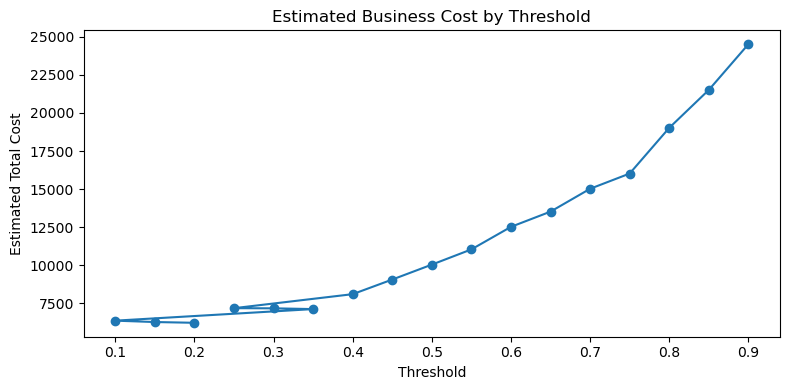

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(cost_threshold_df["threshold"], cost_threshold_df["Estimated_Total_Cost"], marker="o")
plt.title("Estimated Business Cost by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Estimated Total Cost")
plt.tight_layout()
plt.show()

### Note

> “Instead of stopping at model metrics, I translated false positives and false negatives into estimated business cost. That helped me discuss threshold choice in terms stakeholders care about, not just machine learning scores.”

## 19. Final notes and next steps

### Summary
- The notebook works directly with **`creditcard.csv`**
- The data is split into **train and test sets** using a **stratified split**
- I added lightweight, explainable feature engineering around **amount** and **transaction timing**
- I compared:
  - Baseline Logistic Regression
  - Logistic Regression with **SMOTE**
  - Logistic Regression with **ADASYN**
  - Decision Tree models
  - Random Forest models
- I evaluated the best model using fraud-relevant metrics and added a simple **business cost analysis**

### What to say
- This was an **imbalanced classification** problem, so I did not rely on accuracy alone
- I focused on **PR-AUC, recall, and F1**
- I used resampling methods to improve learning on the minority fraud class
- I added a threshold and business-cost discussion to make the project more practical

### Next steps for a stronger production version
1. Tune hyperparameters with cross-validation
2. Add a validation split separate from the final holdout test
3. Calibrate predicted probabilities
4. Use time-aware validation if transaction chronology matters
5. Export the best pipeline and build a lightweight prediction API